In [49]:
# Parte 1 - Explorar a préprocessar métricas do Instagram, extraídos do Dashboard do Metabusiness
# Analise Exploratória dos dados Quantitativos extraídos do Metabusiness do Instagram
# Este arquivo tem a finalidade de explorar os dados captados

#importação dos módulos para o processamento dos dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [50]:
#importando arquivos
#importacao_dados-instagram
insta = pd.read_excel('de_2017_2025.xlsx')

In [51]:
#Analisar o conteúdo da tabela
insta.head()


,Identificação da publicação,Identificação da conta,Nome de usuário da conta,Nome da conta,Descrição,Duração (segundos),Horário de publicação,Link permanente,Tipo de publicação,Comentário de dados,Data,Curtidas,Compartilhamentos,Seguimentos,Comentários,Salvamentos,Alcance,Visualizações
0,17875946206063960,17841403718029750,revistaembarque,RevistaEmbarque,"O Le Vin Bistro, em São Paulo, Rio de Janeiro ...",0,04/04/2017 09:50,https://www.instagram.com/p/BSeIShDgltG/,Imagem do Instagram,NaN,Vitalício,14,0,0.0,0,0,NaN,NaN
1,17876661535017550,17841403718029750,revistaembarque,RevistaEmbarque,A companhia aérea Avianca vai iniciar voos int...,0,04/04/2017 12:21,https://www.instagram.com/p/BSeZkffgUI7/,Imagem do Instagram,NaN,Vitalício,17,0,0.0,0,0,NaN,NaN
2,17876386039003670,17841403718029750,revistaembarque,RevistaEmbarque,Companhia aérea britânica Monarch Airlines va...,0,04/04/2017 13:11,https://www.instagram.com/p/BSefNFXAJQC/,Imagem do Instagram,NaN,Vitalício,31,0,0.0,3,0,NaN,NaN
3,17853516142164990,17841403718029750,revistaembarque,RevistaEmbarque,"Para celebrar a Páscoa, a companhia aérea Gol ...",0,04/11/2017 13:02,https://www.instagram.com/p/BSwfytsgKrP/,Imagem do Instagram,NaN,Vitalício,9,0,0.0,0,0,NaN,NaN
4,17879804671030280,17841403718029750,revistaembarque,RevistaEmbarque,"O Hotel Shangri-La Paris, na charmosa capital ...",0,04/11/2017 13:05,https://www.instagram.com/p/BSwgH5SgxYx/,Imagem do Instagram,NaN,Vitalício,13,0,0.0,0,0,NaN,NaN


In [52]:
#verificação os tipos de variáveis
insta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1678 entries, 0 to 1677
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Identificação da publicação  1678 non-null   int64  
 1   Identificação da conta       1678 non-null   int64  
 2   Nome de usuário da conta     1678 non-null   object 
 3   Nome da conta                1678 non-null   object 
 4   Descrição                    1670 non-null   object 
 5   Duração (segundos)           1678 non-null   int64  
 6   Horário de publicação        1678 non-null   object 
 7   Link permanente              1678 non-null   object 
 8   Tipo de publicação           1678 non-null   object 
 9   Comentário de dados          0 non-null      float64
 10  Data                         1678 non-null   object 
 11  Curtidas                     1678 non-null   int64  
 12  Compartilhamentos            1678 non-null   int64  
 13  Seguimentos       

In [53]:
insta.tail(6)

,Identificação da publicação,Identificação da conta,Nome de usuário da conta,Nome da conta,Descrição,Duração (segundos),Horário de publicação,Link permanente,Tipo de publicação,Comentário de dados,Data,Curtidas,Compartilhamentos,Seguimentos,Comentários,Salvamentos,Alcance,Visualizações
1672,18443959756070648,17841403718029750,revistaembarque,RevistaEmbarque,✈A Embraer está com oportunidades de estágios ...,0,09/26/2024 08:00,https://www.instagram.com/p/DAYnVrrMEbB/,Imagem do Instagram,NaN,Vitalício,0,0,NaN,0,1,47.0,56.0
1673,18061783765657432,17841403718029750,revistaembarque,RevistaEmbarque,✈ Conheça a nova pintura do avião da GOL do pr...,0,09/25/2024 16:00,https://www.instagram.com/p/DAW5gFNsBE5/,Carrossel do Instagram,NaN,Vitalício,2,0,NaN,0,0,93.0,142.0
1674,18284021740236220,17841403718029750,revistaembarque,RevistaEmbarque,✈A LATAM recebeu pela primeira vez uma aeronav...,0,09/25/2024 15:00,https://www.instagram.com/p/DAWynnNu5Jd/,Imagem do Instagram,NaN,Vitalício,2,0,NaN,0,0,125.0,139.0
1675,18100433221436500,17841403718029750,revistaembarque,RevistaEmbarque,✈Após ter 75% de sua pista de pousos e decolag...,0,09/04/2024 19:33,https://www.instagram.com/p/C_hNJqaPVAm/,Imagem do Instagram,NaN,Vitalício,2,0,NaN,0,0,138.0,188.0
1676,18097577962451192,17841403718029750,revistaembarque,RevistaEmbarque,✈A Câmara aprovou nesta quarta-feira (28) proj...,0,09/04/2024 08:00,https://www.instagram.com/p/C_f94AUCp6k/,Imagem do Instagram,NaN,Vitalício,2,0,NaN,0,0,130.0,160.0
1677,17902934870986890,17841403718029750,revistaembarque,RevistaEmbarque,💛Todo ano a Revista Embarque apoia essa import...,0,09/03/2024 09:14,https://www.instagram.com/p/C_dhiY9MNPd/,Imagem do Instagram,NaN,Vitalício,0,0,NaN,0,0,30.0,36.0


In [54]:
#remoção as 4 últimas colunas do banco insta
#remoção as 4 ultimas linha do banco que são NAN
insta = insta.iloc[:-4]

In [55]:
insta.tail(4)

,Identificação da publicação,Identificação da conta,Nome de usuário da conta,Nome da conta,Descrição,Duração (segundos),Horário de publicação,Link permanente,Tipo de publicação,Comentário de dados,Data,Curtidas,Compartilhamentos,Seguimentos,Comentários,Salvamentos,Alcance,Visualizações
1670,18059017606740032,17841403718029750,revistaembarque,RevistaEmbarque,🎗 Outubro Rosa: Juntos na Luta Contra o Câncer...,0,10/01/2024 11:12,https://www.instagram.com/p/DAl1W7dOjya/,Imagem do Instagram,NaN,Vitalício,3,1,NaN,0,0,93.0,100.0
1671,18017107868304448,17841403718029750,revistaembarque,RevistaEmbarque,✈A Força de Defesa Nacional da África do Sul a...,0,09/26/2024 11:00,https://www.instagram.com/p/DAY79cJtEn9/,Imagem do Instagram,NaN,Vitalício,2,0,NaN,0,0,65.0,81.0
1672,18443959756070648,17841403718029750,revistaembarque,RevistaEmbarque,✈A Embraer está com oportunidades de estágios ...,0,09/26/2024 08:00,https://www.instagram.com/p/DAYnVrrMEbB/,Imagem do Instagram,NaN,Vitalício,0,0,NaN,0,1,47.0,56.0
1673,18061783765657432,17841403718029750,revistaembarque,RevistaEmbarque,✈ Conheça a nova pintura do avião da GOL do pr...,0,09/25/2024 16:00,https://www.instagram.com/p/DAW5gFNsBE5/,Carrossel do Instagram,NaN,Vitalício,2,0,NaN,0,0,93.0,142.0


In [56]:
#Tarefas antes de iniciar os graficos
"""tranformando identificadores das contas em inteiros
Identificação da publicação  1678 non-null   float64
Identificação da conta       1678 non-null   float64"""

insta['Identificação da publicação']=insta['Identificação da publicação'].astype(int)
insta['Identificação da conta']=insta['Identificação da conta'].astype(int)


In [57]:
insta.head()

,Identificação da publicação,Identificação da conta,Nome de usuário da conta,Nome da conta,Descrição,Duração (segundos),Horário de publicação,Link permanente,Tipo de publicação,Comentário de dados,Data,Curtidas,Compartilhamentos,Seguimentos,Comentários,Salvamentos,Alcance,Visualizações
0,17875946206063960,17841403718029750,revistaembarque,RevistaEmbarque,"O Le Vin Bistro, em São Paulo, Rio de Janeiro ...",0,04/04/2017 09:50,https://www.instagram.com/p/BSeIShDgltG/,Imagem do Instagram,NaN,Vitalício,14,0,0.0,0,0,NaN,NaN
1,17876661535017550,17841403718029750,revistaembarque,RevistaEmbarque,A companhia aérea Avianca vai iniciar voos int...,0,04/04/2017 12:21,https://www.instagram.com/p/BSeZkffgUI7/,Imagem do Instagram,NaN,Vitalício,17,0,0.0,0,0,NaN,NaN
2,17876386039003670,17841403718029750,revistaembarque,RevistaEmbarque,Companhia aérea britânica Monarch Airlines va...,0,04/04/2017 13:11,https://www.instagram.com/p/BSefNFXAJQC/,Imagem do Instagram,NaN,Vitalício,31,0,0.0,3,0,NaN,NaN
3,17853516142164990,17841403718029750,revistaembarque,RevistaEmbarque,"Para celebrar a Páscoa, a companhia aérea Gol ...",0,04/11/2017 13:02,https://www.instagram.com/p/BSwfytsgKrP/,Imagem do Instagram,NaN,Vitalício,9,0,0.0,0,0,NaN,NaN
4,17879804671030280,17841403718029750,revistaembarque,RevistaEmbarque,"O Hotel Shangri-La Paris, na charmosa capital ...",0,04/11/2017 13:05,https://www.instagram.com/p/BSwgH5SgxYx/,Imagem do Instagram,NaN,Vitalício,13,0,0.0,0,0,NaN,NaN


In [58]:
# Verificando tipos de variáveis
insta['Horário de publicação'].info()

insta.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1674 entries, 0 to 1673
Series name: Horário de publicação
Non-Null Count  Dtype 
--------------  ----- 
1674 non-null   object
dtypes: object(1)
memory usage: 13.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1674 entries, 0 to 1673
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Identificação da publicação  1674 non-null   int64  
 1   Identificação da conta       1674 non-null   int64  
 2   Nome de usuário da conta     1674 non-null   object 
 3   Nome da conta                1674 non-null   object 
 4   Descrição                    1666 non-null   object 
 5   Duração (segundos)           1674 non-null   int64  
 6   Horário de publicação        1674 non-null   object 
 7   Link permanente              1674 non-null   object 
 8   Tipo de publicação           1674 non-null   object 
 9   Comentário de dados          0 no

In [59]:
# Conversão de object para data
#data_n = pd.to_datetime(insta['Horário de publicação'], dayfirst=True, errors='coerce')
data_n = pd.to_datetime(insta['Horário de publicação'])

In [60]:
# Criar uma nova coluna no formato dia/mês/ano
insta['data_formatada'] = data_n.dt.strftime('%d/%m/%Y')

In [61]:
insta.columns

Index(['Identificação da publicação', 'Identificação da conta',
       'Nome de usuário da conta', 'Nome da conta', 'Descrição',
       'Duração (segundos)', 'Horário de publicação', 'Link permanente',
       'Tipo de publicação', 'Comentário de dados', 'Data', 'Curtidas',
       'Compartilhamentos', 'Seguimentos', 'Comentários', 'Salvamentos',
       'Alcance', 'Visualizações', 'data_formatada'],
      dtype='object')

In [62]:
data_n.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1674 entries, 0 to 1673
Series name: Horário de publicação
Non-Null Count  Dtype         
--------------  -----         
1674 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 13.2 KB


In [63]:
insta.tail()

,Identificação da publicação,Identificação da conta,Nome de usuário da conta,Nome da conta,Descrição,Duração (segundos),Horário de publicação,Link permanente,Tipo de publicação,Comentário de dados,Data,Curtidas,Compartilhamentos,Seguimentos,Comentários,Salvamentos,Alcance,Visualizações,data_formatada
1669,18101868250446072,17841403718029750,revistaembarque,RevistaEmbarque,✈Parabéns à KLM! A companhia aérea mais antiga...,53,10/07/2024 13:47,https://www.instagram.com/reel/DA1jsjdPaTv/,Reel do Instagram,NaN,Vitalício,12,0,1.0,0,1,208.0,239.0,07/10/2024
1670,18059017606740032,17841403718029750,revistaembarque,RevistaEmbarque,🎗 Outubro Rosa: Juntos na Luta Contra o Câncer...,0,10/01/2024 11:12,https://www.instagram.com/p/DAl1W7dOjya/,Imagem do Instagram,NaN,Vitalício,3,1,NaN,0,0,93.0,100.0,01/10/2024
1671,18017107868304448,17841403718029750,revistaembarque,RevistaEmbarque,✈A Força de Defesa Nacional da África do Sul a...,0,09/26/2024 11:00,https://www.instagram.com/p/DAY79cJtEn9/,Imagem do Instagram,NaN,Vitalício,2,0,NaN,0,0,65.0,81.0,26/09/2024
1672,18443959756070648,17841403718029750,revistaembarque,RevistaEmbarque,✈A Embraer está com oportunidades de estágios ...,0,09/26/2024 08:00,https://www.instagram.com/p/DAYnVrrMEbB/,Imagem do Instagram,NaN,Vitalício,0,0,NaN,0,1,47.0,56.0,26/09/2024
1673,18061783765657432,17841403718029750,revistaembarque,RevistaEmbarque,✈ Conheça a nova pintura do avião da GOL do pr...,0,09/25/2024 16:00,https://www.instagram.com/p/DAW5gFNsBE5/,Carrossel do Instagram,NaN,Vitalício,2,0,NaN,0,0,93.0,142.0,25/09/2024


In [64]:
# Preenchimento dos campos NAN(vazios) neste caso para contagem por zeros, Substituir NAN por zeros:
# Estes Campos estavam vazios nos anos anteriores
"""
Curtidas                     1679 non-null   float64
Compartilhamentos            1679 non-null   float64
Seguimentos                  823 non-null    float64
Comentários                  1679 non-null   float64
Salvamentos                  1679 non-null   float64
Alcance                      732 non-null    float64
Visualizações                198 non-null    float64"""

insta[['Curtidas','Compartilhamentos','Seguimentos','Comentários','Salvamentos','Alcance','Visualizações']]=insta[['Curtidas','Compartilhamentos','Seguimentos','Comentários','Salvamentos','Alcance','Visualizações']].fillna(0)

In [66]:
#Tipo de publicação
#removeu-se o final com str.replace('do instagram')
insta['Tipo de publicação']=insta['Tipo de publicação'].str.replace('do Instagram', '',regex=False)
insta['Tipo de publicação'] = insta['Tipo de publicação'].str.replace('do Instagram', '', regex=False)

In [67]:
# Valores únicos da coluna
print(insta['Tipo de publicação'].unique())

# Quantidade de linhas que não terminam com 'do instagram'
print((~insta['Tipo de publicação'].str.endswith('do instagram', na=False)).sum())


['Imagem ' 'Reel ' 'IGTV' 'Carrossel ']
1674


In [69]:
#Remove dos tipos de publicação a menção "do instagram", fica mais fácil identificar os tipos únicos de publicação analisados

diferentes = insta[~insta['Tipo de publicação'].str.endswith('do instagram', na=False)]
print(diferentes)


      Identificação da publicação  Identificação da conta  \
0               17875946206063960       17841403718029750   
1               17876661535017550       17841403718029750   
2               17876386039003670       17841403718029750   
3               17853516142164990       17841403718029750   
4               17879804671030280       17841403718029750   
...                           ...                     ...   
1669            18101868250446072       17841403718029750   
1670            18059017606740032       17841403718029750   
1671            18017107868304448       17841403718029750   
1672            18443959756070648       17841403718029750   
1673            18061783765657432       17841403718029750   

     Nome de usuário da conta    Nome da conta  \
0             revistaembarque  RevistaEmbarque   
1             revistaembarque  RevistaEmbarque   
2             revistaembarque  RevistaEmbarque   
3             revistaembarque  RevistaEmbarque   
4             rev

In [71]:
# Verifica se existe, na coluna "Tipo de publicação", algum valor diferente de "do Instagram

existe_diferente = (~insta['Tipo de publicação'].str.endswith('do Instagram', na=False)).any()
print(existe_diferente)


True


In [72]:
# # Verifica se existe, na coluna "Tipo de publicação", algum valor diferente de "do Instagram e cria instacia insta_deferentes


insta_diferentes = insta[~insta['Tipo de publicação'].str.endswith('do Instagram', na=False)]
print(insta_diferentes)


      Identificação da publicação  Identificação da conta  \
0               17875946206063960       17841403718029750   
1               17876661535017550       17841403718029750   
2               17876386039003670       17841403718029750   
3               17853516142164990       17841403718029750   
4               17879804671030280       17841403718029750   
...                           ...                     ...   
1669            18101868250446072       17841403718029750   
1670            18059017606740032       17841403718029750   
1671            18017107868304448       17841403718029750   
1672            18443959756070648       17841403718029750   
1673            18061783765657432       17841403718029750   

     Nome de usuário da conta    Nome da conta  \
0             revistaembarque  RevistaEmbarque   
1             revistaembarque  RevistaEmbarque   
2             revistaembarque  RevistaEmbarque   
3             revistaembarque  RevistaEmbarque   
4             rev

In [73]:

# Remover link e seção do instagram de publicação e deixar shortcode
# A ideia aqui é caso fosse necessário gerar uma nova tabel consolidade com os links caso fosse necessário acessar


insta['shortcode'] = insta['Link permanente'].str.extract(r'/p/([^/]+)/')

In [74]:
# Tabela com shortcode (link da publicação) para acesso da publicação


insta['shortcode']

,shortcode
0,BSeIShDgltG
1,BSeZkffgUI7
2,BSefNFXAJQC
3,BSwfytsgKrP
4,BSwgH5SgxYx
...,...
1669,NaN
1670,DAl1W7dOjya
1671,DAY79cJtEn9
1672,DAYnVrrMEbB


In [75]:
insta.columns

Index(['Identificação da publicação', 'Identificação da conta',
       'Nome de usuário da conta', 'Nome da conta', 'Descrição',
       'Duração (segundos)', 'Horário de publicação', 'Link permanente',
       'Tipo de publicação', 'Comentário de dados', 'Data', 'Curtidas',
       'Compartilhamentos', 'Seguimentos', 'Comentários', 'Salvamentos',
       'Alcance', 'Visualizações', 'data_formatada', 'shortcode'],
      dtype='object')

In [76]:
#criar uma coluna ano
# Criar uma coluna com o ano
insta['Ano'] = pd.to_datetime(insta['data_formatada'], format='%d/%m/%Y', errors='coerce').dt.year


In [ ]:
insta['Ano']

,Ano
0,2017
1,2017
2,2017
3,2017
4,2017
...,...
1673,2024
1674,2024
1675,2024
1676,2024


In [77]:
#criando nova tabela de dados
insta_ = insta[['shortcode', 'Identificação da conta', 'Identificação da publicação', 'Curtidas', 'Compartilhamentos', 'Seguimentos', 'Comentários', 'Salvamentos', 'Alcance', 'Visualizações', 'Ano']]

In [79]:
# Nova tabela com o shorcode

insta_

,shortcode,Identificação da conta,Identificação da publicação,Curtidas,Compartilhamentos,Seguimentos,Comentários,Salvamentos,Alcance,Visualizações,Ano
0,BSeIShDgltG,17841403718029750,17875946206063960,14,0,0.0,0,0,0.0,0.0,2017
1,BSeZkffgUI7,17841403718029750,17876661535017550,17,0,0.0,0,0,0.0,0.0,2017
2,BSefNFXAJQC,17841403718029750,17876386039003670,31,0,0.0,3,0,0.0,0.0,2017
3,BSwfytsgKrP,17841403718029750,17853516142164990,9,0,0.0,0,0,0.0,0.0,2017
4,BSwgH5SgxYx,17841403718029750,17879804671030280,13,0,0.0,0,0,0.0,0.0,2017
...,...,...,...,...,...,...,...,...,...,...,...
1669,NaN,17841403718029750,18101868250446072,12,0,1.0,0,1,208.0,239.0,2024
1670,DAl1W7dOjya,17841403718029750,18059017606740032,3,1,0.0,0,0,93.0,100.0,2024
1671,DAY79cJtEn9,17841403718029750,18017107868304448,2,0,0.0,0,0,65.0,81.0,2024
1672,DAYnVrrMEbB,17841403718029750,18443959756070648,0,0,0.0,0,1,47.0,56.0,2024


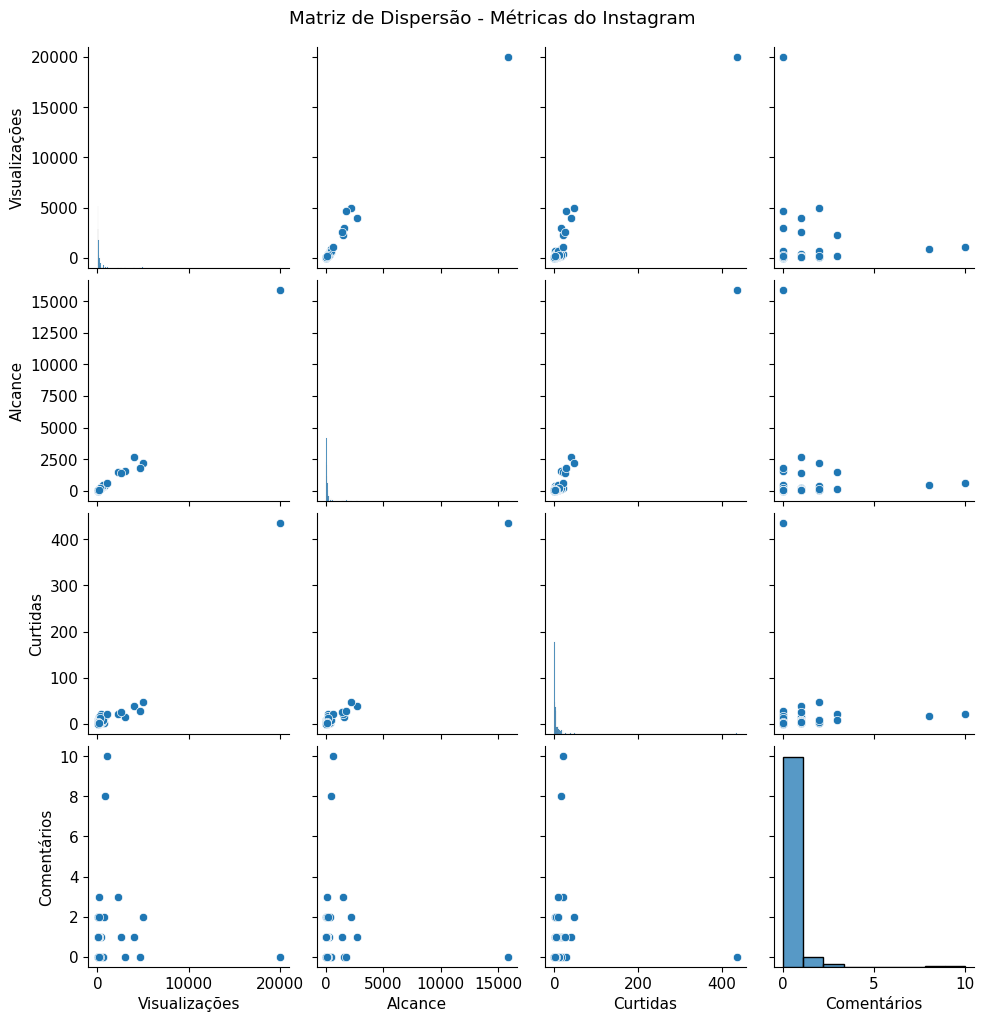

In [81]:
# Gráfico de Dispersão - Matriz de dispersão
# verificação de possíveis relações entre as variáveis

import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas as variáveis numéricas de interesse
df_disp = insta_[['Visualizações', 'Alcance', 'Curtidas', 'Comentários']]

# Remover possíveis valores extremos (opcional, mas recomendado)
df_disp = df_disp[df_disp['Visualizações'] > 0]

# Criar a matriz de dispersão
sns.pairplot(df_disp)

# Título geral (opcional)
plt.suptitle('Matriz de Dispersão - Métricas do Instagram', y=1.02)

# Exibir
plt.show()

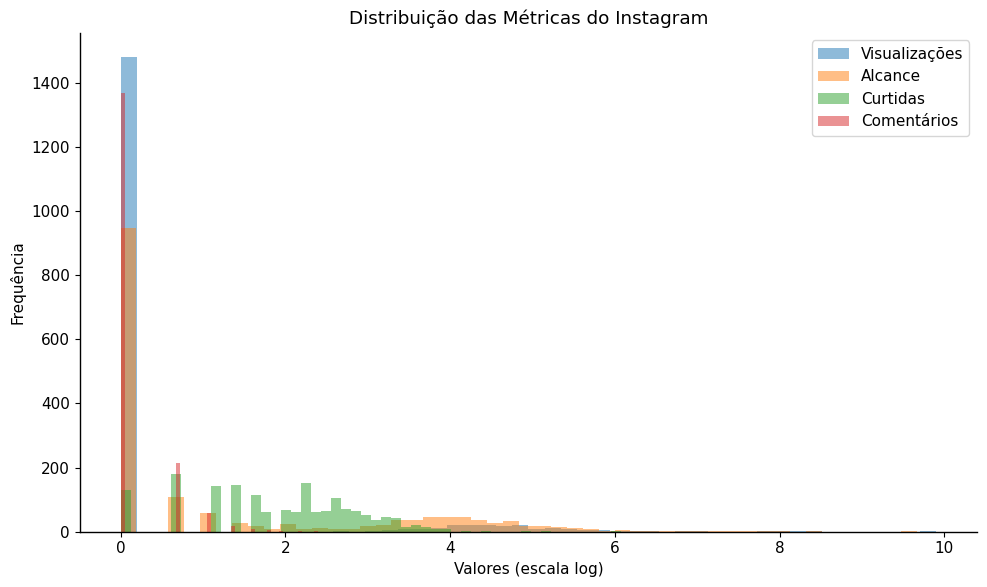

In [83]:
# Gráfico de distribuição das métricas - histograma
# Mostrar como os valores das métricas estão distribuídos

import matplotlib.pyplot as plt
import numpy as np

# Selecionar variáveis
df_dist = insta_[['Visualizações', 'Alcance', 'Curtidas', 'Comentários']]

# Aplicar log para melhorar distribuição
df_dist_log = np.log1p(df_dist)

# Criar gráfico
plt.figure(figsize=(10,6))

for coluna in df_dist_log.columns:
    plt.hist(df_dist_log[coluna], bins=50, alpha=0.5, label=coluna)

# Configurações
plt.xlabel('Valores (escala log)')
plt.ylabel('Frequência')
plt.title('Distribuição das Métricas do Instagram')
plt.legend()

# =========================
# REMOVER CAIXA (ESTILO LIMPO)
# =========================

ax = plt.gca()

# Remove bordas superior e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mantém apenas eixo X e Y
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# Ajustar espessura dos eixos
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Remover grade (opcional)
ax.grid(False)

# Layout final
plt.tight_layout()
plt.show()

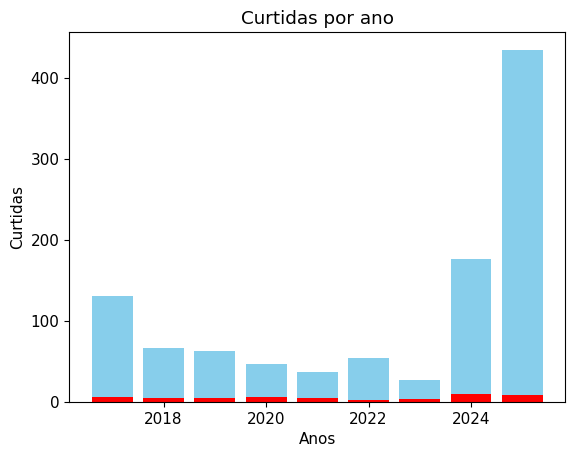

In [85]:

# Explorando dados da Embarque

#Totalização de todos os anos
import matplotlib.pyplot as plt

# Criando o gráfico de barras
plt.bar(insta_['Ano'], insta_['Curtidas'], color='skyblue')
plt.bar(insta_['Ano'], insta_['Comentários'], color='red')
# Títulos e rótulos
plt.title('Curtidas por ano')
plt.xlabel('Anos')
plt.ylabel('Curtidas')

# Exibir o gráfico
plt.show()

Liberation Sans Narrow
Liberation Sans Narrow
Humor Sans
Liberation Sans Narrow
Liberation Serif
Liberation Serif
Liberation Mono
Liberation Sans
Liberation Sans
Liberation Mono
Liberation Mono
Liberation Serif
Liberation Serif
Liberation Mono
Liberation Sans
Liberation Sans
Liberation Sans Narrow


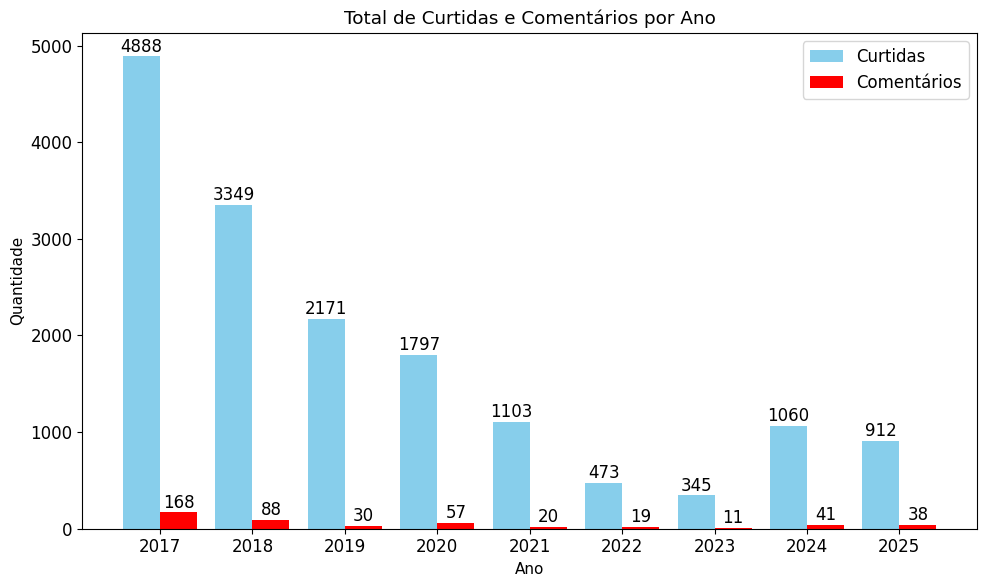

In [87]:
# Totais de curtidas e comentários

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.font_manager

for f in matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf'):
    print(matplotlib.font_manager.FontProperties(fname=f).get_name())

# Configurando a fonte global
rcParams['font.family'] = 'Arial'

# Criar a largura das barras
bar_width = 0.4
anos = insta_['Ano'].unique()
anos.sort()

# Posicionar as barras
r1 = np.arange(len(anos))
r2 = [x + bar_width for x in r1]

# Somar as curtidas e comentários por ano
curtidas_por_ano = insta_.groupby('Ano')['Curtidas'].sum()
comentarios_por_ano = insta_.groupby('Ano')['Comentários'].sum()

# Criar o gráfico de barras lado a lado
plt.figure(figsize=(10,6))
plt.bar(r1, curtidas_por_ano, color='skyblue', width=bar_width, label='Curtidas')
plt.bar(r2, comentarios_por_ano, color='red', width=bar_width, label='Comentários')

# Adicionar os valores em cima de cada barra
for i in range(len(anos)):
    plt.text(r1[i], curtidas_por_ano.iloc[i] + 50, int(curtidas_por_ano.iloc[i]), ha='center', fontsize=12)
    plt.text(r2[i], comentarios_por_ano.iloc[i] + 50, int(comentarios_por_ano.iloc[i]), ha='center', fontsize=12)

# Ajustar o eixo x
plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.title('Total de Curtidas e Comentários por Ano')
#plt.xticks([r + bar_width/2 for r in r1], anos)
plt.xticks([r + bar_width/2 for r in r1], anos, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Adicionar legenda
plt.legend(fontsize=12)

# Exibir o gráfico
plt.tight_layout()
# Salvando o gráfico como imagem PNG
plt.savefig('curtidas_comentarios_ano.png', dpi=300, bbox_inches='tight')
plt.show()



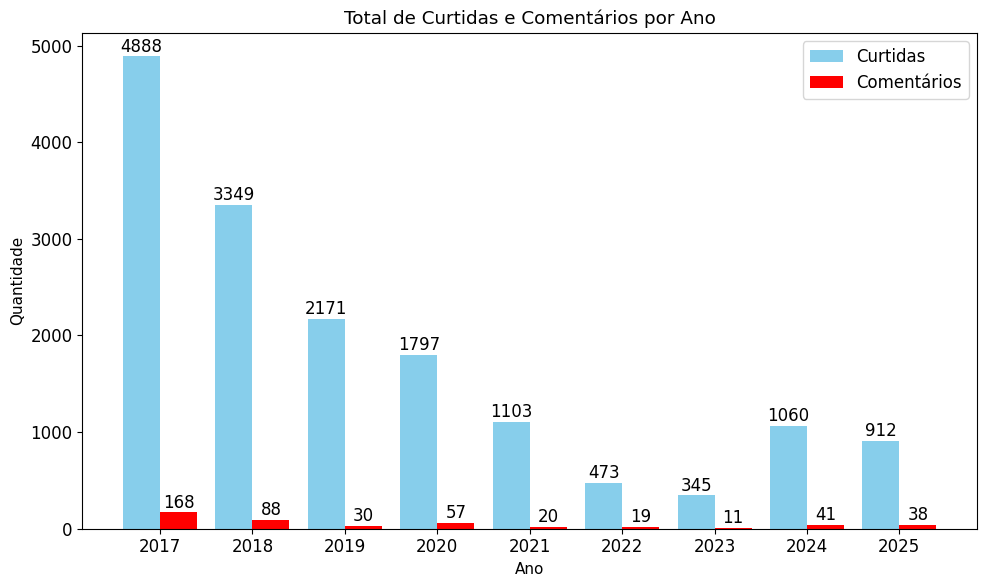

In [88]:
# Totais Curtidas e Comentários

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.font_manager


# Criar a largura das barras
bar_width = 0.4
anos = insta_['Ano'].unique()
anos.sort()

# Posicionar as barras
r1 = np.arange(len(anos))
r2 = [x + bar_width for x in r1]

# Somar as curtidas e comentários por ano
curtidas_por_ano = insta_.groupby('Ano')['Curtidas'].sum()
comentarios_por_ano = insta_.groupby('Ano')['Comentários'].sum()

# Criar o gráfico de barras lado a lado
plt.figure(figsize=(10,6))
plt.bar(r1, curtidas_por_ano, color='skyblue', width=bar_width, label='Curtidas')
plt.bar(r2, comentarios_por_ano, color='red', width=bar_width, label='Comentários')

# Adicionar os valores em cima de cada barra
for i in range(len(anos)):
    plt.text(r1[i], curtidas_por_ano.iloc[i] + 50, int(curtidas_por_ano.iloc[i]), ha='center', fontsize=12)
    plt.text(r2[i], comentarios_por_ano.iloc[i] + 50, int(comentarios_por_ano.iloc[i]), ha='center', fontsize=12)

# Ajustar o eixo x
plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.title('Total de Curtidas e Comentários por Ano')
plt.xticks([r + bar_width/2 for r in r1], anos, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Adicionar legenda
plt.legend(fontsize=12)

# Exibir o gráfico
plt.tight_layout()
# Salvando o gráfico como imagem PNG
plt.savefig('curtidas_comentarios_ano.png', dpi=300, bbox_inches='tight')
# plt.show() # Remova o comentário se quiser exibir o gráfico em uma janela

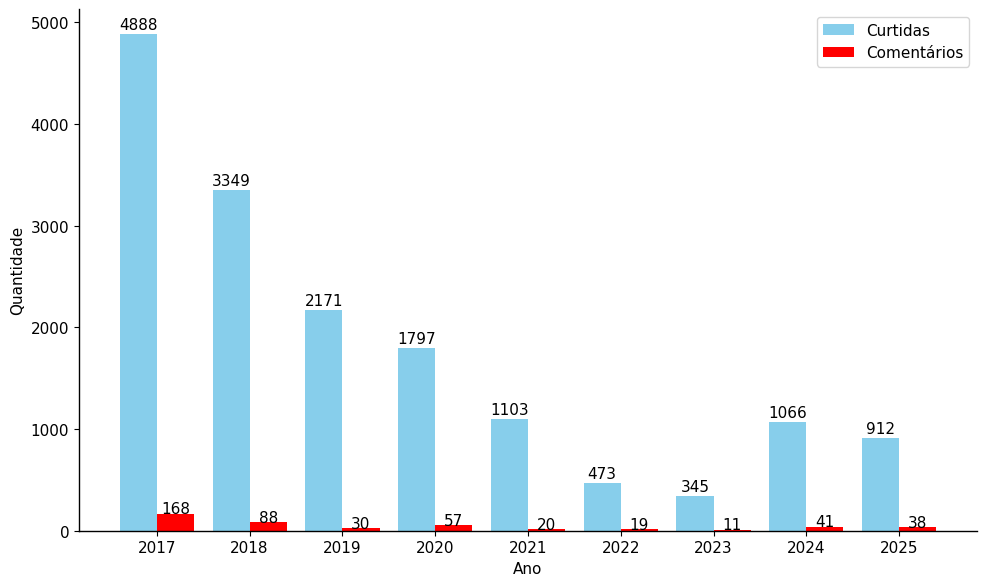

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Configurar a fonte global como Arial 11
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 11

# Filtrar os dados para remover ano zero
insta_filtrado = insta_[insta_['Ano'] > 0]

# Criar a largura das barras
bar_width = 0.4
anos = sorted(insta_filtrado['Ano'].unique())

# Posicionar as barras
r1 = np.arange(len(anos))
r2 = [x + bar_width for x in r1]

# Somar os totais por ano
curtidas_por_ano = insta_filtrado.groupby('Ano')['Curtidas'].sum()
comentarios_por_ano = insta_filtrado.groupby('Ano')['Comentários'].sum()

# Criar o gráfico de barras lado a lado
plt.figure(figsize=(10, 6))
plt.bar(r1, curtidas_por_ano, color='skyblue', width=bar_width, label='Curtidas')
plt.bar(r2, comentarios_por_ano, color='red', width=bar_width, label='Comentários')

# Adicionar os totais em cima de cada barra
for i in range(len(anos)):
    plt.text(r1[i], curtidas_por_ano.iloc[i] + curtidas_por_ano.max() * 0.01, int(curtidas_por_ano.iloc[i]),
             ha='center', fontsize=11)
    plt.text(r2[i], comentarios_por_ano.iloc[i] + comentarios_por_ano.max() * 0.01, int(comentarios_por_ano.iloc[i]),
             ha='center', fontsize=11)

# Configurar os rótulos dos eixos
plt.xlabel('Ano', fontsize=11)
plt.ylabel('Quantidade', fontsize=11)

# Configurar os ticks do eixo X
plt.xticks([r + bar_width / 2 for r in r1], anos, fontsize=11)

# Configurar os ticks do eixo Y
plt.yticks(fontsize=11)

# Adicionar legenda
plt.legend(fontsize=11)

# Remover a moldura (bordas) deixando só os eixos X e Y
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Layout final
plt.tight_layout()
plt.savefig('curtidas_comentarios_ano.png', dpi=300, bbox_inches='tight')
plt.show()


In [92]:
# Estatísticas descritivas das variáveis Curtidas e Comentários

# Agrupando por Ano
estatisticas = insta_.groupby('Ano')[['Curtidas', 'Comentários']].agg(['mean', 'median', 'std'])

# Arredondando para 2 casas decimais
estatisticas = estatisticas.round(2)

print(estatisticas)



     Curtidas               Comentários             
         mean median    std        mean median   std
Ano                                                 
2017    18.66   15.0  12.79        0.64    0.0  1.10
2018    14.88   13.0   8.59        0.39    0.0  0.73
2019    15.62   12.0  11.53        0.22    0.0  0.54
2020     7.75    7.0   5.52        0.25    0.0  0.67
2021     6.77    5.0   5.94        0.12    0.0  0.54
2022     3.31    2.0   4.98        0.13    0.0  0.42
2023     2.28    1.0   3.71        0.07    0.0  0.35
2024     4.00    2.0  12.46        0.15    0.0  0.75
2025     9.70    3.0  44.72        0.40    0.0  1.03


In [93]:
# Exportando arquivo

estatisticas.to_csv('estatisticas_por_ano.csv', index=True)


In [95]:

# Médias do total de comentários e curtidas
print(insta_[['Curtidas', 'Comentários']].agg(['mean', 'median', 'std']))


         Curtidas  Comentários
mean     9.616487     0.281959
median   6.000000     0.000000
std     15.067169     0.763371


In [96]:
# Resumo Estatístico
estatisticas = insta_.groupby('Ano')[['Curtidas', 'Comentários']].agg(['mean', 'median', 'std'])

# Tabela Resumo Estatístico
estatisticas.style.format("{:.2f}").set_caption("Resumo Estatístico: Curtidas e Comentários por Ano")


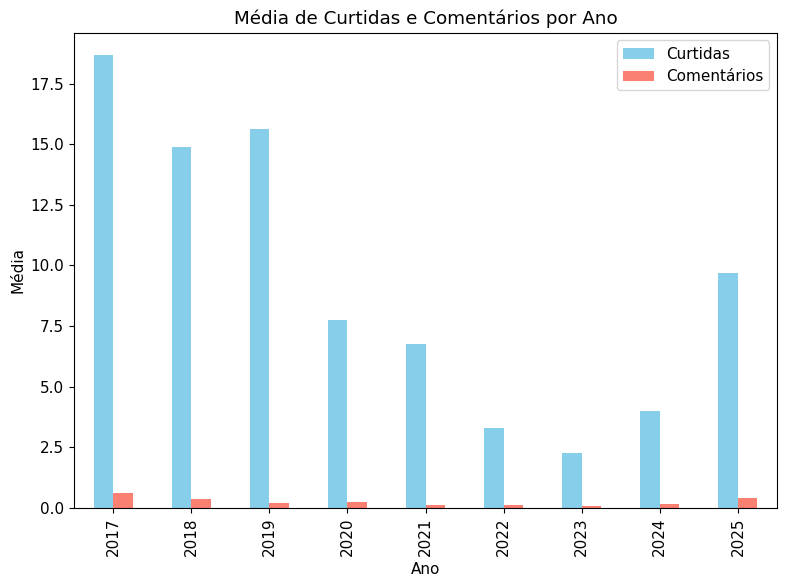

In [97]:
import matplotlib.pyplot as plt

# Calcula a média por ano
medias = insta_.groupby('Ano')[['Curtidas', 'Comentários']].mean()

# Plotando
medias.plot(kind='bar', figsize=(8,6), color=['skyblue', 'salmon'])
plt.title('Média de Curtidas e Comentários por Ano')
plt.ylabel('Média')
plt.xlabel('Ano')
plt.tight_layout()
plt.show()


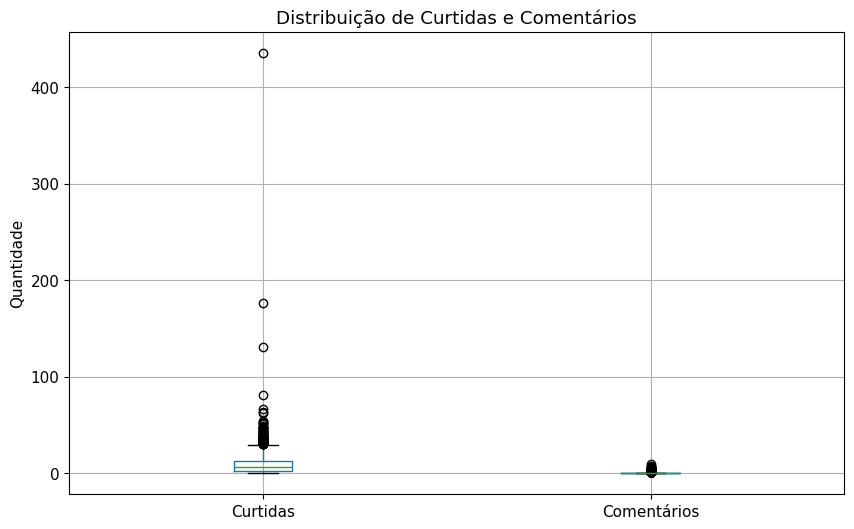

In [98]:

# Gráfico Box-plot
# Distribuição de um conjunto de dados numéricos

plt.figure(figsize=(10,6))
insta_.boxplot(column=['Curtidas', 'Comentários'])
plt.title('Distribuição de Curtidas e Comentários')
plt.ylabel('Quantidade')
plt.show()


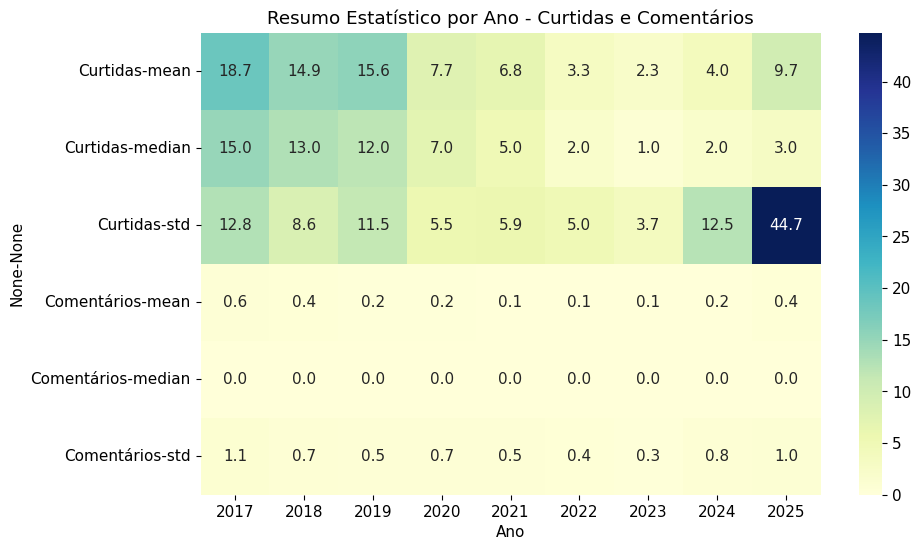

In [99]:
# Mapa de Calor com as metricas dos comentários e Cutidas

import seaborn as sns

# Resumo estatístico por ano
estatisticas_plot = insta_.groupby('Ano')[['Curtidas', 'Comentários']].agg(['mean', 'median', 'std'])

plt.figure(figsize=(10,6))
sns.heatmap(estatisticas_plot.T, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Resumo Estatístico por Ano - Curtidas e Comentários')
plt.show()


In [100]:
# Dados Brutos relacionados à Alcance e visualização

In [101]:
insta.head()

,Identificação da publicação,Identificação da conta,Nome de usuário da conta,Nome da conta,Descrição,Duração (segundos),Horário de publicação,Link permanente,Tipo de publicação,Comentário de dados,...,Curtidas,Compartilhamentos,Seguimentos,Comentários,Salvamentos,Alcance,Visualizações,data_formatada,shortcode,Ano
0,17875946206063960,17841403718029750,revistaembarque,RevistaEmbarque,"O Le Vin Bistro, em São Paulo, Rio de Janeiro ...",0,04/04/2017 09:50,https://www.instagram.com/p/BSeIShDgltG/,Imagem,NaN,...,14,0,0.0,0,0,0.0,0.0,04/04/2017,BSeIShDgltG,2017
1,17876661535017550,17841403718029750,revistaembarque,RevistaEmbarque,A companhia aérea Avianca vai iniciar voos int...,0,04/04/2017 12:21,https://www.instagram.com/p/BSeZkffgUI7/,Imagem,NaN,...,17,0,0.0,0,0,0.0,0.0,04/04/2017,BSeZkffgUI7,2017
2,17876386039003670,17841403718029750,revistaembarque,RevistaEmbarque,Companhia aérea britânica Monarch Airlines va...,0,04/04/2017 13:11,https://www.instagram.com/p/BSefNFXAJQC/,Imagem,NaN,...,31,0,0.0,3,0,0.0,0.0,04/04/2017,BSefNFXAJQC,2017
3,17853516142164990,17841403718029750,revistaembarque,RevistaEmbarque,"Para celebrar a Páscoa, a companhia aérea Gol ...",0,04/11/2017 13:02,https://www.instagram.com/p/BSwfytsgKrP/,Imagem,NaN,...,9,0,0.0,0,0,0.0,0.0,11/04/2017,BSwfytsgKrP,2017
4,17879804671030280,17841403718029750,revistaembarque,RevistaEmbarque,"O Hotel Shangri-La Paris, na charmosa capital ...",0,04/11/2017 13:05,https://www.instagram.com/p/BSwgH5SgxYx/,Imagem,NaN,...,13,0,0.0,0,0,0.0,0.0,11/04/2017,BSwgH5SgxYx,2017


In [102]:
insta_.to_excel('insta_final.xlsx', index=False)

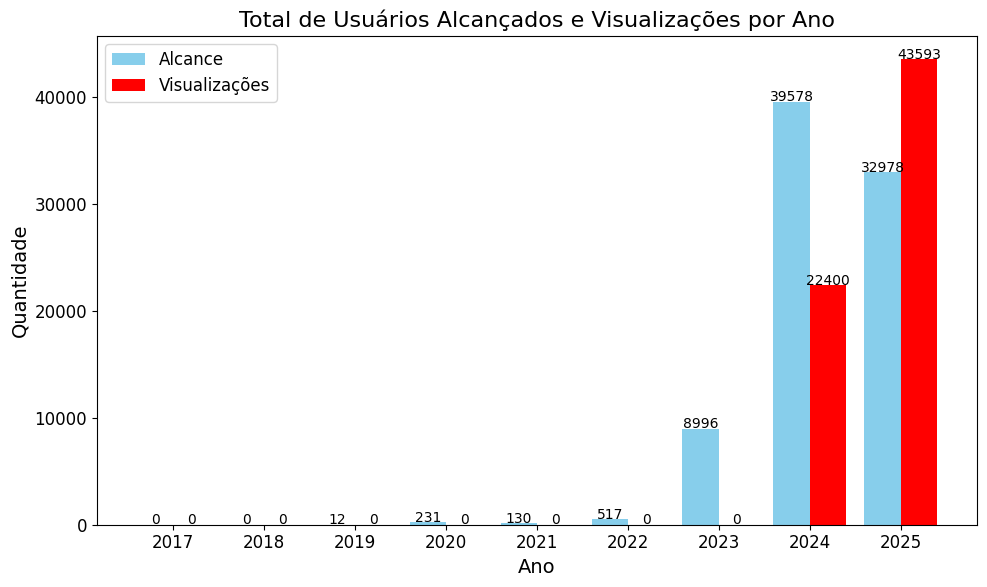

In [104]:
# Explorando as variáveis Alcance e Visualizações

import numpy as np
import matplotlib.pyplot as plt

# Criar a largura das barras
bar_width = 0.4
anos = sorted(insta_['Ano'].unique())

# Garantir que "anos" esteja como uma lista simples
anos = list(anos)

# Posicionar as barras
r1 = np.arange(len(anos))
r2 = [x + bar_width for x in r1]

# Somar os totais por ano
alcance_por_ano = insta_.groupby('Ano')['Alcance'].sum()
visualizacoes_por_ano = insta_.groupby('Ano')['Visualizações'].sum()

# Criar o gráfico de barras lado a lado
plt.figure(figsize=(10, 6))
plt.bar(r1, alcance_por_ano, color='skyblue', width=bar_width, label='Alcance')
plt.bar(r2, visualizacoes_por_ano, color='red', width=bar_width, label='Visualizações')

# Adicionar os valores em cima de cada barra
for i in range(len(anos)):
    plt.text(r1[i], alcance_por_ano.iloc[i] + 50, int(alcance_por_ano.iloc[i]), ha='center', fontsize=10)
    plt.text(r2[i], visualizacoes_por_ano.iloc[i] + 50, int(visualizacoes_por_ano.iloc[i]), ha='center', fontsize=10)

# Ajustar os ticks do eixo x
plt.xlabel('Ano', fontsize=14)
plt.ylabel('Quantidade', fontsize=14)
plt.title('Total de Usuários Alcançados e Visualizações por Ano', fontsize=16)

# Ajustar as labels do eixo x
plt.xticks([r + bar_width / 2 for r in r1], anos, fontsize=12)

plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Melhor layout
plt.tight_layout()

# Salvar a imagem
plt.savefig('alcance_visualizacoes_ano.png', dpi=300, bbox_inches='tight')

# Exibir o gráfico
plt.show()


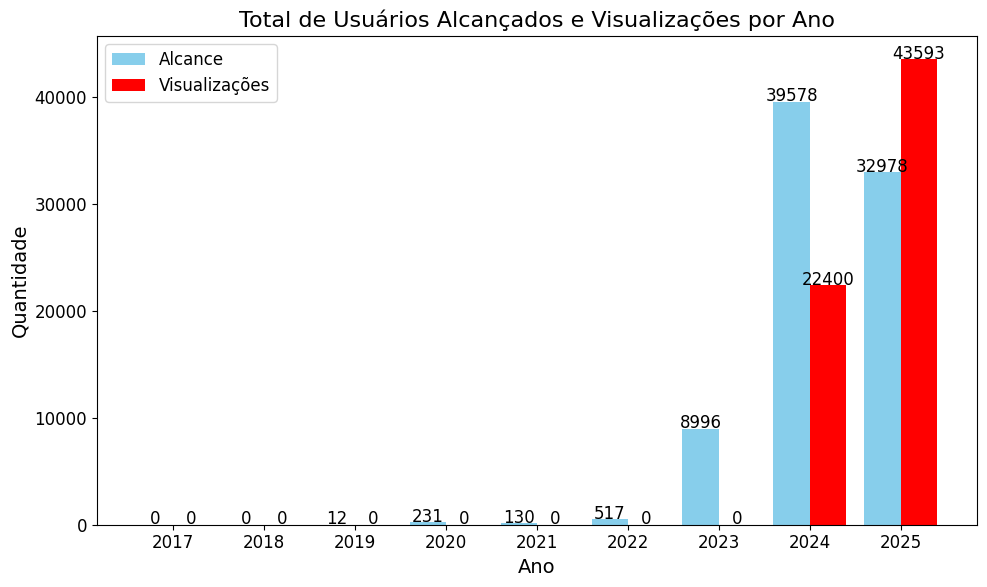

In [106]:
# Explorando as variáveis Alcance e Visualizações

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Configurando a fonte global
rcParams['font.family'] = 'Arial'

# Filtrar os dados para remover ano zero
insta_filtrado = insta_[insta_['Ano'] > 0]

# Criar a largura das barras
bar_width = 0.4
anos = sorted(insta_filtrado['Ano'].unique())

# Posicionar as barras
r1 = np.arange(len(anos))
r2 = [x + bar_width for x in r1]

# Somar os totais por ano
alcance_por_ano = insta_filtrado.groupby('Ano')['Alcance'].sum()
visualizacoes_por_ano = insta_filtrado.groupby('Ano')['Visualizações'].sum()

# Criar o gráfico de barras lado a lado
plt.figure(figsize=(10, 6))
plt.bar(r1, alcance_por_ano, color='skyblue', width=bar_width, label='Alcance')
plt.bar(r2, visualizacoes_por_ano, color='red', width=bar_width, label='Visualizações')

# Adicionar os valores em cima de cada barra
for i in range(len(anos)):
    plt.text(r1[i], alcance_por_ano.iloc[i] + 50, int(alcance_por_ano.iloc[i]), ha='center', fontsize=12)
    plt.text(r2[i], visualizacoes_por_ano.iloc[i] + 50, int(visualizacoes_por_ano.iloc[i]), ha='center', fontsize=12)

# Ajustar os ticks do eixo x
plt.xlabel('Ano', fontsize=14)
plt.ylabel('Quantidade', fontsize=14)
plt.title('Total de Usuários Alcançados e Visualizações por Ano', fontsize=16)

# Ajustar as labels do eixo x
plt.xticks([r + bar_width / 2 for r in r1], anos, fontsize=12)

plt.yticks(fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.savefig('alcance_visualizacoes_ano.png', dpi=300, bbox_inches='tight')
plt.show()


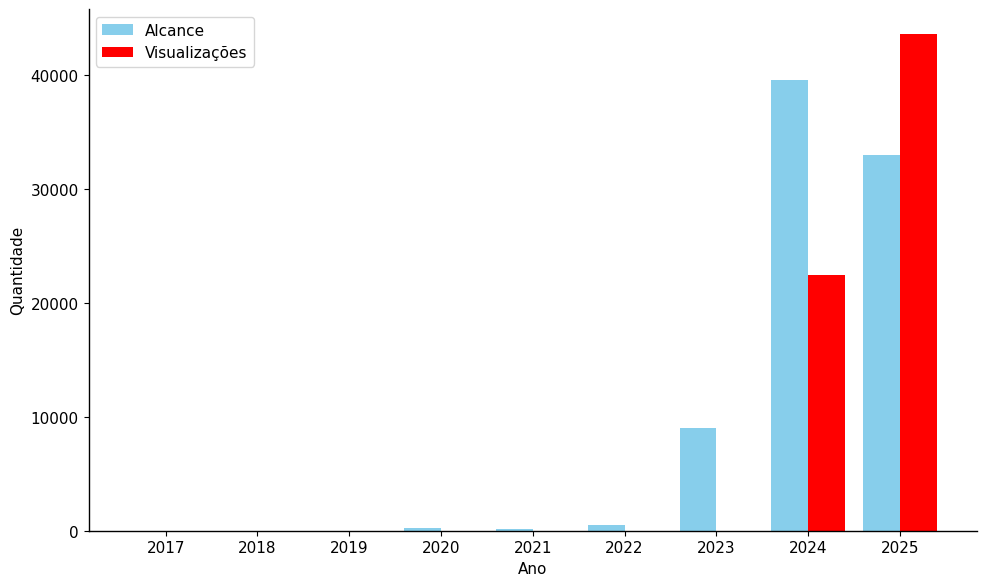

In [108]:
# Testando remoção de Grid superior e Esquerdo

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Configurar a fonte global como Arial 11
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 11

# Filtrar os dados para remover ano zero
insta_filtrado = insta_[insta_['Ano'] > 0]

# Criar a largura das barras
bar_width = 0.4
anos = sorted(insta_filtrado['Ano'].unique())

# Posicionar as barras
r1 = np.arange(len(anos))
r2 = [x + bar_width for x in r1]

# Somar os totais por ano
alcance_por_ano = insta_filtrado.groupby('Ano')['Alcance'].sum()
visualizacoes_por_ano = insta_filtrado.groupby('Ano')['Visualizações'].sum()

# Criar o gráfico de barras lado a lado
plt.figure(figsize=(10, 6))
plt.bar(r1, alcance_por_ano, color='skyblue', width=bar_width, label='Alcance')
plt.bar(r2, visualizacoes_por_ano, color='red', width=bar_width, label='Visualizações')

# Configurar os rótulos dos eixos
plt.xlabel('Ano', fontsize=11)
plt.ylabel('Quantidade', fontsize=11)

# Configurar os ticks do eixo X
plt.xticks([r + bar_width / 2 for r in r1], anos, fontsize=11)

# Configurar os ticks do eixo Y
plt.yticks(fontsize=11)

# Adicionar legenda
plt.legend(fontsize=11)

# Remover a caixa (bordas) do gráfico, deixando só os eixos X e Y
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# Opcional: deixar as linhas dos eixos um pouco mais grossas (se quiser)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Layout final
plt.tight_layout()
plt.savefig('alcance_visualizacoes_ano.png', dpi=300, bbox_inches='tight')
plt.show()


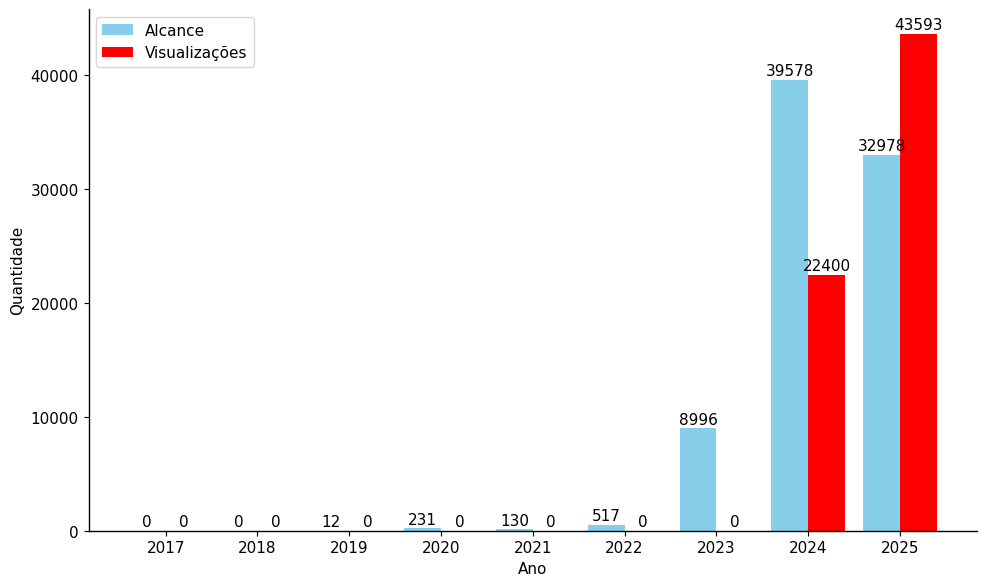

In [109]:
# Explorando alcance e visualizações
# Grafico padrão para entrega

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Configurar a fonte global como Arial 11
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 11

# Filtrar os dados para remover ano zero
insta_filtrado = insta_[insta_['Ano'] > 0]

# Criar a largura das barras
bar_width = 0.4
anos = sorted(insta_filtrado['Ano'].unique())

# Posicionar as barras
r1 = np.arange(len(anos))
r2 = [x + bar_width for x in r1]

# Somar os totais por ano
alcance_por_ano = insta_filtrado.groupby('Ano')['Alcance'].sum()
visualizacoes_por_ano = insta_filtrado.groupby('Ano')['Visualizações'].sum()

# Criar o gráfico de barras lado a lado
plt.figure(figsize=(10, 6))
plt.bar(r1, alcance_por_ano, color='skyblue', width=bar_width, label='Alcance')
plt.bar(r2, visualizacoes_por_ano, color='red', width=bar_width, label='Visualizações')

# Adicionar os totais em cima de cada barra
for i in range(len(anos)):
    plt.text(r1[i], alcance_por_ano.iloc[i] + alcance_por_ano.max() * 0.01, int(alcance_por_ano.iloc[i]),
             ha='center', fontsize=11)
    plt.text(r2[i], visualizacoes_por_ano.iloc[i] + visualizacoes_por_ano.max() * 0.01, int(visualizacoes_por_ano.iloc[i]),
             ha='center', fontsize=11)

# Configurar os rótulos dos eixos
plt.xlabel('Ano', fontsize=11)
plt.ylabel('Quantidade', fontsize=11)

# Configurar os ticks do eixo X
plt.xticks([r + bar_width / 2 for r in r1], anos, fontsize=11)

# Configurar os ticks do eixo Y
plt.yticks(fontsize=11)

# Adicionar legenda
plt.legend(fontsize=11)

# Remover a moldura (bordas) deixando só os eixos X e Y
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Layout final
plt.tight_layout()
plt.savefig('alcance_visualizacoes_ano.png', dpi=300, bbox_inches='tight')
plt.show()


In [110]:
insta.tail(100)

,Identificação da publicação,Identificação da conta,Nome de usuário da conta,Nome da conta,Descrição,Duração (segundos),Horário de publicação,Link permanente,Tipo de publicação,Comentário de dados,...,Curtidas,Compartilhamentos,Seguimentos,Comentários,Salvamentos,Alcance,Visualizações,data_formatada,shortcode,Ano
1574,18034694290415580,17841403718029750,revistaembarque,RevistaEmbarque,"✈A Air Europa firmou um codeshare, ou acordo d...",0,12/13/2022 16:12,https://www.instagram.com/p/CmILb-3s0Fj/,Imagem,NaN,...,2,0,0.0,0,0,11.0,0.0,13/12/2022,CmILb-3s0Fj,2022
1575,17942994635324090,17841403718029750,revistaembarque,RevistaEmbarque,✈O Brasil tem quatro dos dez melhores aeroport...,0,12/13/2022 16:01,https://www.instagram.com/p/CmIKOm_gODj/,Carrossel,NaN,...,4,0,0.0,0,0,2.0,0.0,13/12/2022,CmIKOm_gODj,2022
1576,17988512020656440,17841403718029750,revistaembarque,RevistaEmbarque,🇦🇷A Argentina se classificou para a final da C...,0,12/13/2022 13:19,https://www.instagram.com/p/CmH3p4igyaD/,Imagem,NaN,...,4,0,0.0,0,0,0.0,0.0,13/12/2022,CmH3p4igyaD,2022
1577,18226497328081248,17841403718029750,revistaembarque,RevistaEmbarque,💚 Que tristeza! Mais uma Copa e o sonho do Hex...,0,12/09/2022 10:21,https://www.instagram.com/p/Cl9QJ-kL7Ch/,Imagem,NaN,...,13,0,0.0,2,0,2.0,0.0,09/12/2022,Cl9QJ-kL7Ch,2022
1578,17891831192674160,17841403718029750,revistaembarque,RevistaEmbarque,✈ Confira os bastidores do Airbus A321 da LATA...,41,12/09/2022 08:17,https://www.instagram.com/reel/Cl9B5SjJKXO/,Reel,NaN,...,1,0,0.0,2,0,4.0,0.0,09/12/2022,NaN,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1669,18101868250446072,17841403718029750,revistaembarque,RevistaEmbarque,✈Parabéns à KLM! A companhia aérea mais antiga...,53,10/07/2024 13:47,https://www.instagram.com/reel/DA1jsjdPaTv/,Reel,NaN,...,12,0,1.0,0,1,208.0,239.0,07/10/2024,NaN,2024
1670,18059017606740032,17841403718029750,revistaembarque,RevistaEmbarque,🎗 Outubro Rosa: Juntos na Luta Contra o Câncer...,0,10/01/2024 11:12,https://www.instagram.com/p/DAl1W7dOjya/,Imagem,NaN,...,3,1,0.0,0,0,93.0,100.0,01/10/2024,DAl1W7dOjya,2024
1671,18017107868304448,17841403718029750,revistaembarque,RevistaEmbarque,✈A Força de Defesa Nacional da África do Sul a...,0,09/26/2024 11:00,https://www.instagram.com/p/DAY79cJtEn9/,Imagem,NaN,...,2,0,0.0,0,0,65.0,81.0,26/09/2024,DAY79cJtEn9,2024
1672,18443959756070648,17841403718029750,revistaembarque,RevistaEmbarque,✈A Embraer está com oportunidades de estágios ...,0,09/26/2024 08:00,https://www.instagram.com/p/DAYnVrrMEbB/,Imagem,NaN,...,0,0,0.0,0,1,47.0,56.0,26/09/2024,DAYnVrrMEbB,2024


In [112]:
# estatísticas de Alcance e Visualizações

# Agrupando por Ano
estatisticas_visualizacoes = insta_.groupby('Ano')[['Alcance', 'Visualizações']].agg(['mean', 'median', 'std'])

# Arredondando para 2 casas decimais
estatisticas_visualizacoes = estatisticas_visualizacoes.round(2)

print(estatisticas_visualizacoes)

     Alcance                 Visualizações                
        mean median      std          mean median      std
Ano                                                       
2017    0.00    0.0     0.00          0.00    0.0     0.00
2018    0.00    0.0     0.00          0.00    0.0     0.00
2019    0.09    0.0     0.57          0.00    0.0     0.00
2020    1.00    0.0     2.51          0.00    0.0     0.00
2021    0.80    0.0     1.79          0.00    0.0     0.00
2022    3.62    1.0     7.81          0.00    0.0     0.00
2023   59.58   26.0   132.37          0.00    0.0     0.00
2024  149.35   56.0   408.25         84.53    0.0   451.77
2025  350.83  112.0  1653.74        463.76  129.0  2105.35


In [113]:
# Exportando dados transfomados

estatisticas_visualizacoes.to_csv('estatisticas_visualizacoes.csv', index=True)